In [5]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("ggplot")

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [7]:
df = pd.read_parquet('../data/yellow_tripdata_2025-01.parquet')

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [19]:
print(f"Dataset Shape: {df.shape}")
df.info()
df.head()

Dataset Shape: (3475226, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3475226 entries, 0 to 3475225
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64      

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


In [20]:
# 1. Dataset Overview and Column Descriptions

# Column meanings and their relevance for hourly demand prediction:

In [21]:
# Display column descriptions and key information
import json

# Load the schema to understand columns
with open('../yellow_taxi_dictionary.json', 'r') as f:
    schema = json.load(f)

# Create a mapping of column names to descriptions
column_descriptions = {field['field_name']: field.get('description', 'No description') 
                       for field in schema['fields']}

print("=" * 80)
print("DATASET COLUMNS AND DESCRIPTIONS")
print("=" * 80)
for col, desc in column_descriptions.items():
    print(f"\n{col}: {desc}")

print("\n" + "=" * 80)
print(f"Total columns in dataset: {df.shape[1]}")
print(f"Total rows: {df.shape[0]}")
print("=" * 80)

DATASET COLUMNS AND DESCRIPTIONS

VendorID: A code indicating the TPEP provider that provided the record.

tpep_pickup_datetime: The date and time when the meter was engaged.

tpep_dropoff_datetime: The date and time when the meter was disengaged.

passenger_count: The number of passengers in the vehicle.

trip_distance: The elapsed trip distance in miles reported by the taximeter.

RatecodeID: The final rate code in effect at the end of the trip.

store_and_fwd_flag: Indicates whether the trip record was held in vehicle memory before sending (store and forward).

PULocationID: TLC Taxi Zone in which the taximeter was engaged.

DOLocationID: TLC Taxi Zone in which the taximeter was disengaged.

payment_type: A numeric code signifying how the passenger paid for the trip.

fare_amount: The time-and-distance fare calculated by the meter.

extra: Miscellaneous extras and surcharges.

mta_tax: Tax that is automatically triggered based on the metered rate in use.

tip_amount: Tip amount - au

# 2. Data Quality Assessment

Identifying and detecting potential data quality issues:

In [22]:
# Check for missing values
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)
if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("No missing values found!")

# Check for duplicate records
print("\n" + "=" * 80)
print("DUPLICATE RECORDS")
print("=" * 80)
duplicates = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicates}")
print(f"Percentage of dataset: {(duplicates / len(df)) * 100:.2f}%")

# Check data types
print("\n" + "=" * 80)
print("DATA TYPES")
print("=" * 80)
print(df.dtypes)

# Check for potential data quality issues in numeric columns
print("\n" + "=" * 80)
print("NUMERIC COLUMNS - POTENTIAL ANOMALIES")
print("=" * 80)
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    negative_count = (df[col] < 0).sum()
    
    if zero_count > 0 or negative_count > 0:
        print(f"\n{col}:")
        if zero_count > 0:
            print(f"  - Zero values: {zero_count} ({(zero_count/len(df))*100:.2f}%)")
        if negative_count > 0:
            print(f"  - Negative values: {negative_count} ({(negative_count/len(df))*100:.2f}%)")

# Check date ranges
print("\n" + "=" * 80)
print("DATE/TIME RANGES")
print("=" * 80)
print(f"Pickup datetime range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")
print(f"Dropoff datetime range: {df['tpep_dropoff_datetime'].min()} to {df['tpep_dropoff_datetime'].max()}")

# Check invalid trip durations
df['trip_duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
invalid_trips = (df['trip_duration_minutes'] <= 0).sum()
print(f"Trips with invalid duration (dropoff before pickup): {invalid_trips}")

# Check location IDs
print("\n" + "=" * 80)
print("LOCATION IDS")
print("=" * 80)
print(f"Unique pickup zones: {df['PULocationID'].nunique()}")
print(f"Unique dropoff zones: {df['DOLocationID'].nunique()}")
print(f"Location ID range: {df['PULocationID'].min()} to {df['PULocationID'].max()}")
print(f"Unknown/null locations (PU): {(df['PULocationID'] == 0).sum()}")
print(f"Unknown/null locations (DO): {(df['DOLocationID'] == 0).sum()}")


MISSING VALUES
                                    Column  Missing_Count  Missing_Percent
passenger_count            passenger_count         540149        15.542845
RatecodeID                      RatecodeID         540149        15.542845
store_and_fwd_flag      store_and_fwd_flag         540149        15.542845
congestion_surcharge  congestion_surcharge         540149        15.542845
Airport_fee                    Airport_fee         540149        15.542845

DUPLICATE RECORDS
Number of exact duplicate rows: 0
Percentage of dataset: 0.00%

DATA TYPES
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64


# 3. Feature Relevance Analysis for Hourly Taxi Demand Prediction

Which columns are useful for predicting demand (trip count per zone per hour)?

In [8]:
# Extract temporal features from pickup datetime to understand demand patterns
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

print("\n" + "=" * 80)
print("FEATURE RELEVANCE FOR HOURLY DEMAND PREDICTION")
print("=" * 80)

print("\n### KEY FEATURES ###")
print("\nHIGHLY RELEVANT Features:")
print("-" * 80)

print("\n1. PULocationID (Pickup Location):")
print("   - CRITICAL: This is our prediction target at the zone level")
print("   - Used to aggregate trip count per zone per hour")
print(f"   - {df['PULocationID'].nunique()} unique zones")

print("\n2. tpep_pickup_datetime (Pickup Timestamp):")
print("   - CRITICAL: Enables hourly aggregation (our target granularity)")
print("   - Enables extraction of temporal patterns (hour of day, day of week)")
print(f"   - Time range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")

print("\n3. Temporal features (derived from pickup_datetime):")
print(f"   - Pickup hour (0-23): {sorted(df['pickup_hour'].unique())}")
print(f"   - Day of week (0=Mon, 6=Sun): {sorted(df['pickup_day_of_week'].unique())}")
print("   - These capture demand patterns (rush hours, weekday vs weekend)")

print("\n\nLIMITED/REDUCED RELEVANCE Features:")
print("-" * 80)

print("\n1. Trip-level features (not zone-level predictors):")
print("   - tpep_dropoff_datetime, DOLocationID, trip_distance, fare_amount, etc.")
print("   - These describe individual trips but don't directly predict zone demand")
print("   - Could be used for external features (e.g., events at dropoff zones)")

print("\n2. Potentially low-signal features:")
print("   - VendorID: Likely doesn't affect demand patterns")
print("   - payment_type, tip_amount: Describe payment, not demand generation")
print("   - trip_distance, fare_amount: Correlate with demand but aren't predictors")

# Demonstrate aggregation to hourly demand
print("\n" + "=" * 80)
print("EXAMPLE: Aggregating to Hourly Demand Target")
print("=" * 80)

# Create hourly demand by zone
df['hour'] = df['tpep_pickup_datetime'].dt.floor('h')  # Round to hour
hourly_demand = df.groupby(['hour', 'PULocationID']).size().reset_index(name='trip_count')

print(f"\nOriginal data: {len(df)} individual trips")
print(f"After hourly aggregation: {len(hourly_demand)} zone-hour combinations")
print(f"\nSample of hourly demand data:")
print(hourly_demand.head(10).to_string())

print(f"\nDemand statistics:")
print(f"  - Average trips per zone per hour: {hourly_demand['trip_count'].mean():.2f}")
print(f"  - Min: {hourly_demand['trip_count'].min()}, Max: {hourly_demand['trip_count'].max()}")
print(f"  - Std Dev: {hourly_demand['trip_count'].std():.2f}")

# Show which zones have highest demand
print(f"\nTop 10 zones by total trip count:")
zone_demand = df.groupby('PULocationID').size().sort_values(ascending=False)
print(zone_demand.head(10).to_string())


FEATURE RELEVANCE FOR HOURLY DEMAND PREDICTION

### KEY FEATURES ###

HIGHLY RELEVANT Features:
--------------------------------------------------------------------------------

1. PULocationID (Pickup Location):
   - CRITICAL: This is our prediction target at the zone level
   - Used to aggregate trip count per zone per hour
   - 261 unique zones

2. tpep_pickup_datetime (Pickup Timestamp):
   - CRITICAL: Enables hourly aggregation (our target granularity)
   - Enables extraction of temporal patterns (hour of day, day of week)
   - Time range: 2024-12-31 20:47:55 to 2025-02-01 00:00:44

3. Temporal features (derived from pickup_datetime):
   - Pickup hour (0-23): [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]

# 5. Summary & Key Takeaways

In [24]:
print("\n" + "=" * 80)
print("SUMMARY: INSIGHTS FOR WEEK 2 STRUCTURED EDA")
print("=" * 80)

print("\n📊 DATASET SHAPE:")
print(f"   - {df.shape[0]:,} individual trips")
print(f"   - {df.shape[1]} fields per trip")
print(f"   - Data covers: {df['tpep_pickup_datetime'].min().date()} to {df['tpep_pickup_datetime'].max().date()}")

print("\n⚠️  EXPECTED DATA QUALITY CHECKS FOR WEEK 2:")
print("   - Missing values in optional fields (tip_amount, improvement_surcharge, etc.)")
print("   - Negative or zero values in fare, distance, passenger_count")
print("   - Trip duration anomalies (dropoff before pickup)")
print("   - Invalid location IDs (0 or out-of-range zones)")
print("   - Duplicates or exact repeated records")
print("   - Outliers in trip distance and fare amounts")

print("\n🎯 FEATURES FOR PREDICTING HOURLY DEMAND:")
print("   PRIMARY:")
print("   ✓ PULocationID - directly used to aggregate demand by zone")
print("   ✓ tpep_pickup_datetime - enables hourly binning and temporal features")
print("\n   SUPPORTING (for eventual predictive models):")
print("   ✓ Temporal patterns - hour of day, day of week (from pickup time)")
print("   ✓ Historical demand patterns - aggregate past demand by zone+hour")
print("   ✓ External factors - holidays, events, weather (not in this dataset)")
print("\n   NOT USEFUL FOR DIRECT PREDICTION:")
print("   ✗ Trip characteristics (distance, fare, passengers) - describe trips, not demand")
print("   ✗ Dropoff location - describes where trips end, not where they start")
print("   ✗ Payment/vendor info - not predictive of trip generation")


SUMMARY: INSIGHTS FOR WEEK 2 STRUCTURED EDA

📊 DATASET SHAPE:
   - 3,475,226 individual trips
   - 25 fields per trip
   - Data covers: 2024-12-31 to 2025-02-01

⚠️  EXPECTED DATA QUALITY CHECKS FOR WEEK 2:
   - Missing values in optional fields (tip_amount, improvement_surcharge, etc.)
   - Negative or zero values in fare, distance, passenger_count
   - Trip duration anomalies (dropoff before pickup)
   - Invalid location IDs (0 or out-of-range zones)
   - Duplicates or exact repeated records
   - Outliers in trip distance and fare amounts

🎯 FEATURES FOR PREDICTING HOURLY DEMAND:
   PRIMARY:
   ✓ PULocationID - directly used to aggregate demand by zone
   ✓ tpep_pickup_datetime - enables hourly binning and temporal features

   SUPPORTING (for eventual predictive models):
   ✓ Temporal patterns - hour of day, day of week (from pickup time)
   ✓ Historical demand patterns - aggregate past demand by zone+hour
   ✓ External factors - holidays, events, weather (not in this dataset)

   

================================================================================
SUMMARY: INSIGHTS FOR WEEK 2 STRUCTURED EDA
================================================================================

📊 DATASET SHAPE:
   - 3,475,226 individual trips
   - 25 fields per trip
   - Data covers: 2024-12-31 to 2025-02-01

⚠️  EXPECTED DATA QUALITY CHECKS FOR WEEK 2:
   - Missing values in optional fields (tip_amount, improvement_surcharge, etc.)
   - Negative or zero values in fare, distance, passenger_count
   - Trip duration anomalies (dropoff before pickup)
   - Invalid location IDs (0 or out-of-range zones)
   - Duplicates or exact repeated records
   - Outliers in trip distance and fare amounts

🎯 FEATURES FOR PREDICTING HOURLY DEMAND:
   PRIMARY:
   ✓ PULocationID - directly used to aggregate demand by zone
   ✓ tpep_pickup_datetime - enables hourly binning and temporal features

   SUPPORTING (for eventual predictive models):
   ✓ Temporal patterns - hour of day, day of week (from pickup time)
...
   NOT USEFUL FOR DIRECT PREDICTION:
   ✗ Trip characteristics (distance, fare, passengers) - describe trips, not demand
   ✗ Dropoff location - describes where trips end, not where they start
   ✗ Payment/vendor info - not predictive of trip generation

Potential RFE (Recursuve Feature Elimination) for training

1. Remove leakage candidates

2. Run Pearson + MI

3. Run RF Importance

4. Write final feature list

# 4. EDA Charts

A few quick charts to support the demand timing, zone concentration, and the spread of trip economics.

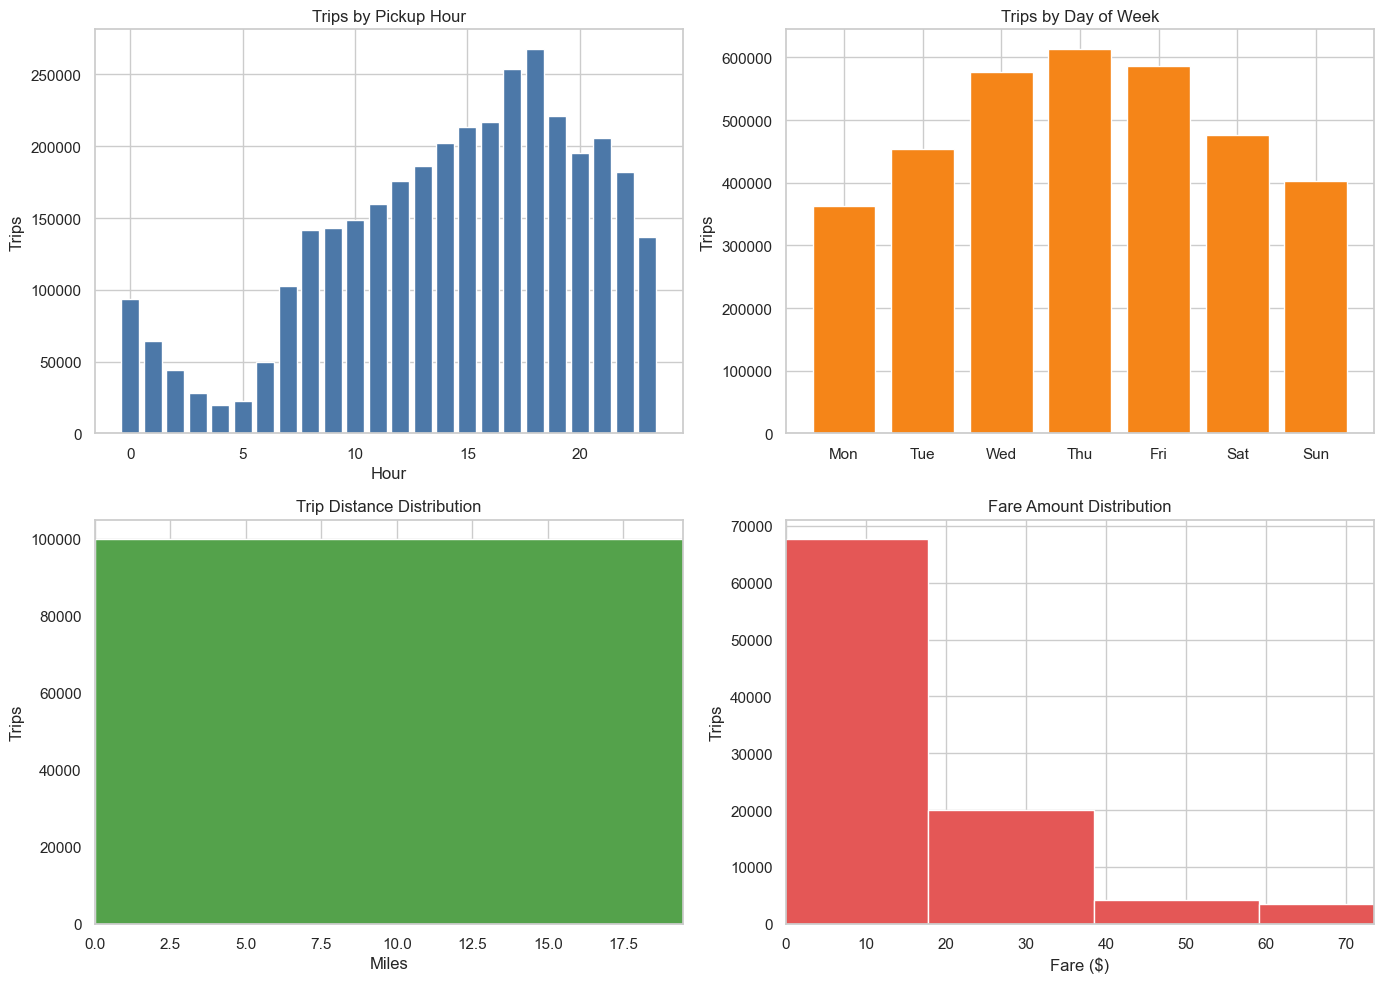

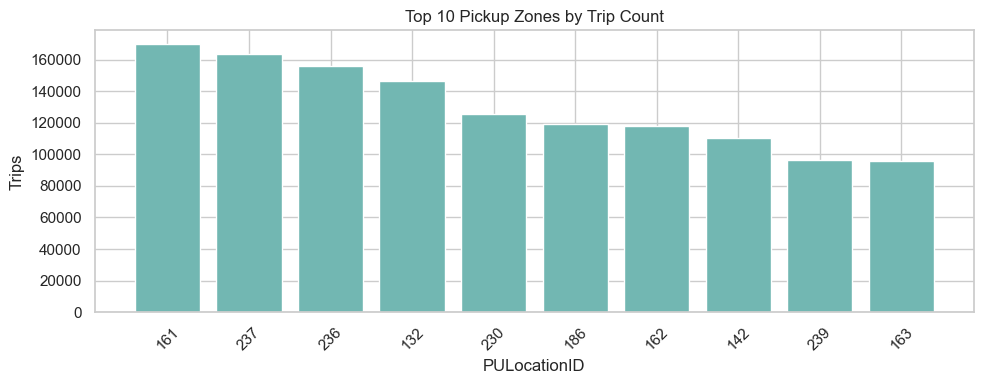

In [25]:
# Surface EDA: demand timing, zone concentration, and variable spread
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
hourly_profile = df.groupby(df["tpep_pickup_datetime"].dt.hour).size().reindex(range(24), fill_value=0)
dow_profile = df.groupby(df["tpep_pickup_datetime"].dt.dayofweek).size().reindex(range(7), fill_value=0)
plot_sample = df[["trip_distance", "fare_amount"]].dropna()
plot_sample = plot_sample.sample(n=min(100000, len(plot_sample)), random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].bar(hourly_profile.index, hourly_profile.values, color="#4C78A8")
axes[0, 0].set_title("Trips by Pickup Hour")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Trips")

axes[0, 1].bar(day_names, dow_profile.values, color="#F58518")
axes[0, 1].set_title("Trips by Day of Week")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Trips")

axes[1, 0].hist(plot_sample["trip_distance"], bins=50, color="#54A24B")
axes[1, 0].set_title("Trip Distance Distribution")
axes[1, 0].set_xlim(0, plot_sample["trip_distance"].quantile(0.99))
axes[1, 0].set_xlabel("Miles")
axes[1, 0].set_ylabel("Trips")

axes[1, 1].hist(plot_sample["fare_amount"], bins=50, color="#E45756")
axes[1, 1].set_title("Fare Amount Distribution")
axes[1, 1].set_xlim(0, plot_sample["fare_amount"].quantile(0.99))
axes[1, 1].set_xlabel("Fare ($)")
axes[1, 1].set_ylabel("Trips")

plt.tight_layout()
plt.show()

top_zones = df.groupby("PULocationID").size().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4))
plt.bar(top_zones.index.astype(str), top_zones.values, color="#72B7B2")
plt.title("Top 10 Pickup Zones by Trip Count")
plt.xlabel("PULocationID")
plt.ylabel("Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The charts support three simple decisions: demand is strongly calendar-driven, pickup zones are concentrated rather than uniform, and trip distance / fare amount are right-skewed with long tails. That means the model should keep time and zone features, and treat trip-economics variables cautiously if they are used at all.

## 4.1 Trip Distance and Fare Amount: Zero/Null Check

A quick look at whether zero or null values are concentrated in the two most important trip economics fields.

,null,zero,valid
trip_distance,0,90893,3384333
fare_amount,0,1398,3473828


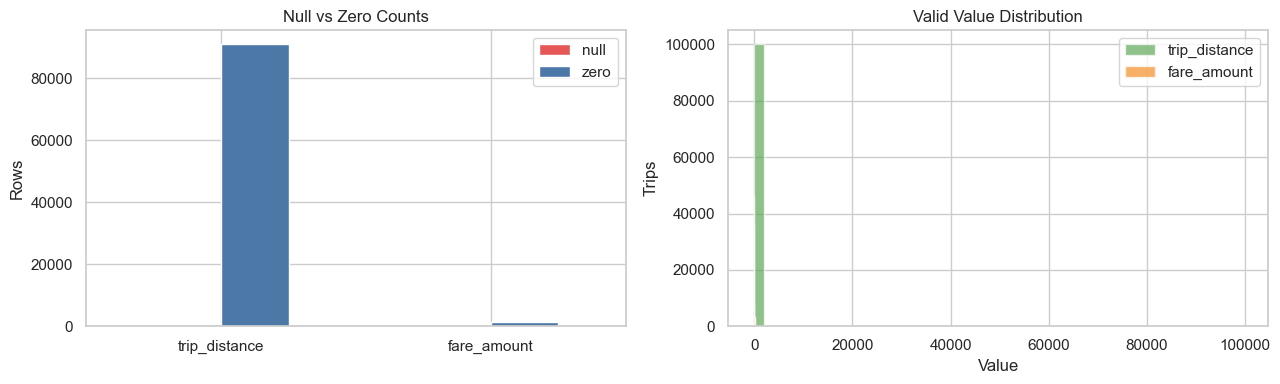

In [26]:
fields = ["trip_distance", "fare_amount"]
status_counts = pd.DataFrame({
    field: {
        "null": df[field].isna().sum(),
        "zero": (df[field] == 0).sum(),
        "valid": df[field].notna().sum() - (df[field] == 0).sum(),
    }
    for field in fields
}).T

display(status_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
status_counts[["null", "zero"]].plot(kind="bar", ax=axes[0], color=["#E45756", "#4C78A8"])
axes[0].set_title("Null vs Zero Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
axes[0].tick_params(axis="x", rotation=0)

clean_sample = df[fields].replace(0, pd.NA).dropna().sample(n=min(100000, len(df[fields].replace(0, pd.NA).dropna())), random_state=42)
axes[1].hist(clean_sample["trip_distance"], bins=50, alpha=0.65, label="trip_distance", color="#54A24B")
axes[1].hist(clean_sample["fare_amount"], bins=50, alpha=0.65, label="fare_amount", color="#F58518")
axes[1].set_title("Valid Value Distribution")
axes[1].set_xlabel("Value")
axes[1].set_ylabel("Trips")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4.2 Trip Distance Cap Check

A quick look at the long tail in trip distance to decide a sensible cap before modeling.

,miles
0.950,11.83
0.975,17.48
0.990,19.50


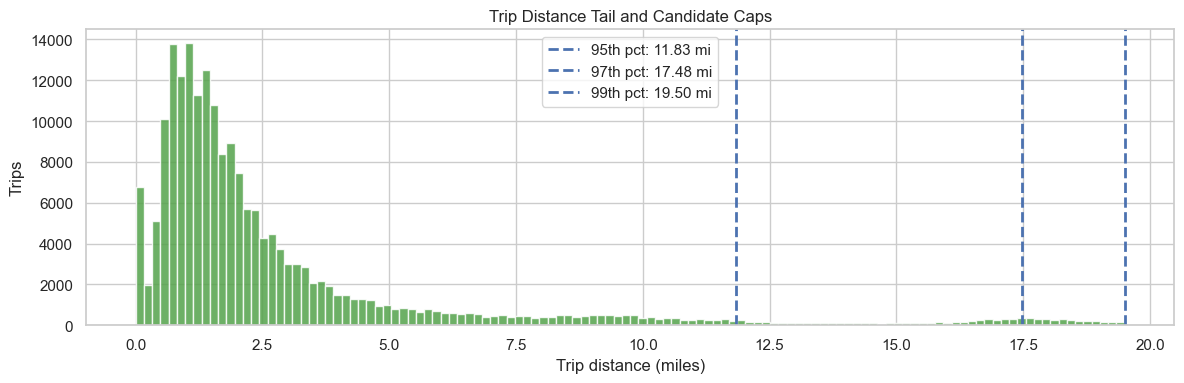

In [27]:
trip_distance = df["trip_distance"].dropna()
distance_caps = trip_distance.quantile([0.95, 0.975, 0.99]).rename("miles")

display(distance_caps.to_frame())

sample_size = min(200000, len(trip_distance))
distance_sample = trip_distance.sample(n=sample_size, random_state=42) if sample_size < len(trip_distance) else trip_distance

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(distance_sample, bins=120, range=(0, trip_distance.quantile(0.99)), color="#54A24B", alpha=0.85)

for q, value in distance_caps.items():
    ax.axvline(value, linestyle="--", linewidth=2, label=f"{int(q * 100)}th pct: {value:.2f} mi")

ax.set_title("Trip Distance Tail and Candidate Caps")
ax.set_xlabel("Trip distance (miles)")
ax.set_ylabel("Trips")
ax.legend()

plt.tight_layout()
plt.show()

## 4.3 Rush Hour and Pickup Zone Patterns

A few fast charts to show when demand peaks, how it varies by weekday, and which pickup zones dominate.

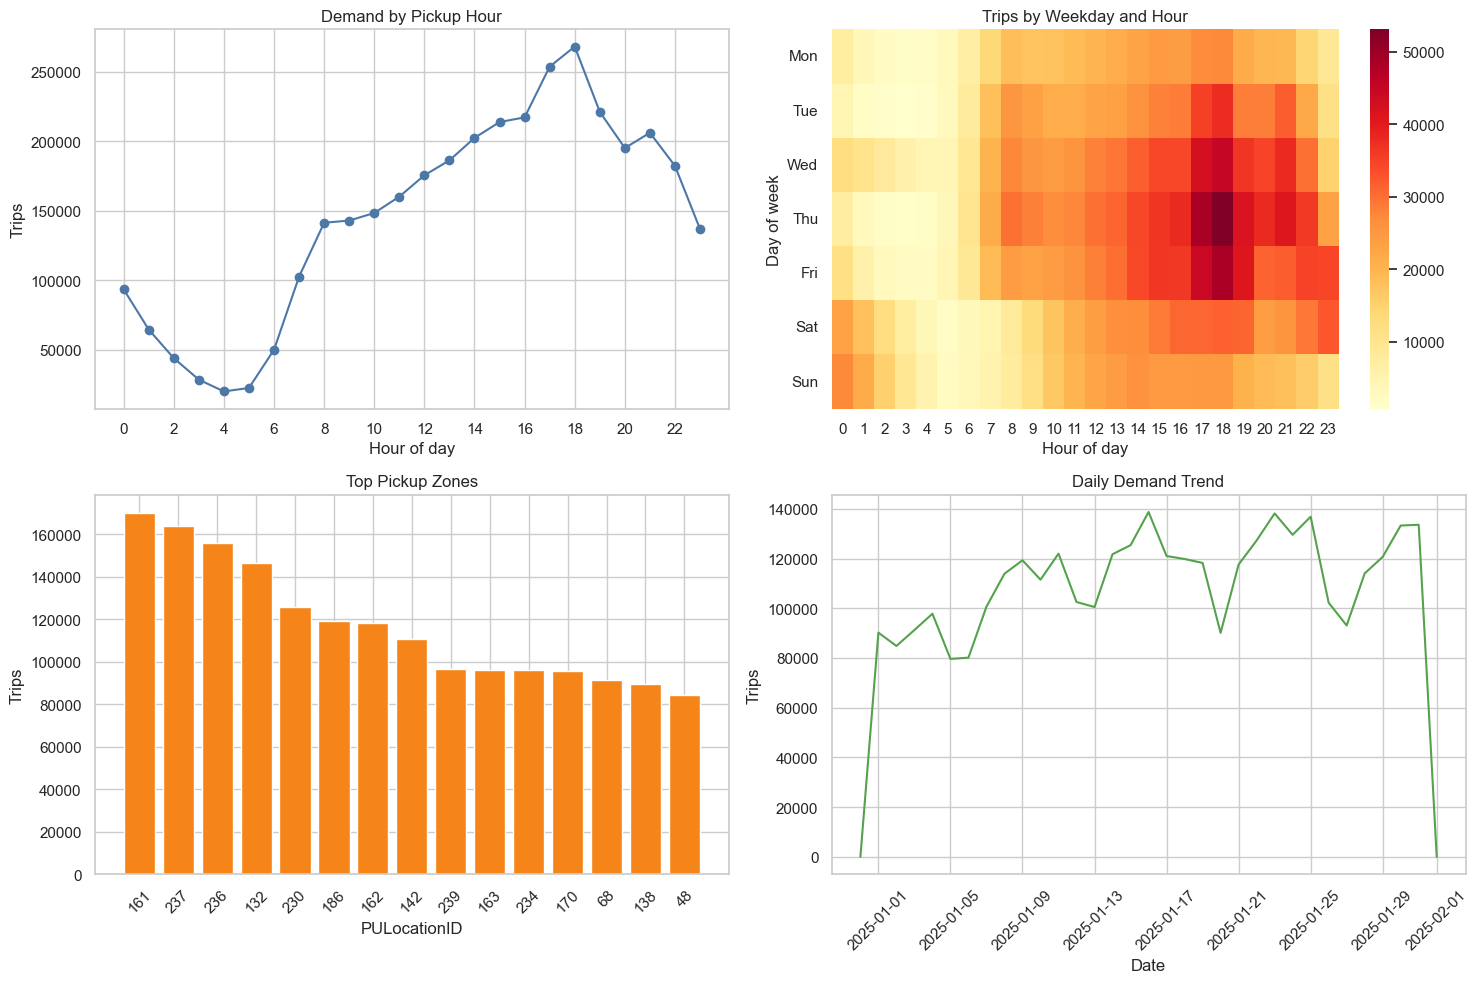

In [29]:
demand_by_hour = df.groupby(df["tpep_pickup_datetime"].dt.hour).size().reindex(range(24), fill_value=0)
demand_by_dow_hour = (
    df.assign(hour=df["tpep_pickup_datetime"].dt.hour, dow=df["tpep_pickup_datetime"].dt.dayofweek)
      .groupby(["dow", "hour"])
      .size()
      .reset_index(name="trips")
      .pivot(index="dow", columns="hour", values="trips")
      .reindex(index=range(7), columns=range(24), fill_value=0)
 )
top_zones = df.groupby("PULocationID").size().sort_values(ascending=False).head(15)
daily_demand = df.groupby(df["tpep_pickup_datetime"].dt.date).size()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].plot(demand_by_hour.index, demand_by_hour.values, marker="o", color="#4C78A8")
axes[0, 0].set_title("Demand by Pickup Hour")
axes[0, 0].set_xlabel("Hour of day")
axes[0, 0].set_ylabel("Trips")
axes[0, 0].set_xticks(range(0, 24, 2))

sns.heatmap(demand_by_dow_hour, cmap="YlOrRd", ax=axes[0, 1])
axes[0, 1].set_title("Trips by Weekday and Hour")
axes[0, 1].set_xlabel("Hour of day")
axes[0, 1].set_ylabel("Day of week")
axes[0, 1].set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)

axes[1, 0].bar(top_zones.index.astype(str), top_zones.values, color="#F58518")
axes[1, 0].set_title("Top Pickup Zones")
axes[1, 0].set_xlabel("PULocationID")
axes[1, 0].set_ylabel("Trips")
axes[1, 0].tick_params(axis="x", rotation=45)

axes[1, 1].plot(daily_demand.index, daily_demand.values, color="#54A24B")
axes[1, 1].set_title("Daily Demand Trend")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Trips")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 4.4 Dataset Temporal Boundaries

Check if trips span into December or February, and compare demand at the dataset's edges.

FIRST 5 TRIPS (earliest pickup times)
  tpep_pickup_datetime tpep_dropoff_datetime  trip_distance  fare_amount
0  2024-12-31 20:47:55   2024-12-31 20:54:00           1.72          9.3
1  2024-12-31 20:52:50   2024-12-31 21:09:34           5.05         23.3
2  2024-12-31 20:54:50   2024-12-31 21:30:18           1.39         28.2
3  2024-12-31 21:15:22   2024-12-31 21:26:00           3.20         15.6
4  2024-12-31 21:20:05   2024-12-31 21:35:13           2.64         16.3

LAST 5 TRIPS (latest pickup times)
        tpep_pickup_datetime tpep_dropoff_datetime  trip_distance  fare_amount
3475221  2025-01-31 23:59:57   2025-02-01 00:07:11           1.37         9.30
3475222  2025-01-31 23:59:58   2025-02-01 00:25:31           3.40        23.30
3475223  2025-01-31 23:59:59   2025-02-01 00:14:17           3.32        18.40
3475224  2025-01-31 23:59:59   2025-02-01 00:12:09           2.11        -4.75
3475225  2025-02-01 00:00:44   2025-02-01 00:05:24           1.04         6.50

TEMPORAL RANG

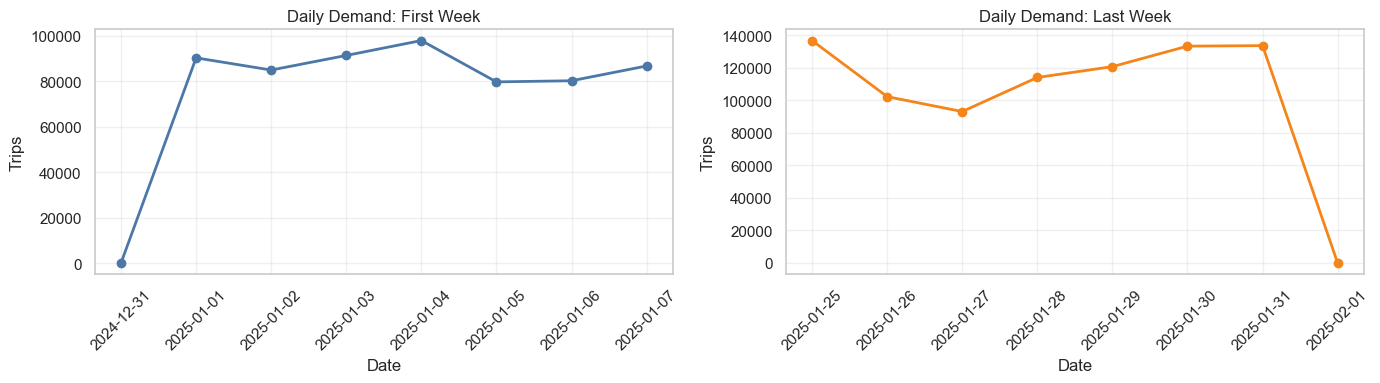

In [ ]:
df_sorted = df.sort_values('tpep_pickup_datetime').reset_index(drop=True)

print("=" * 100)
print("FIRST 5 TRIPS (earliest pickup times)")
print("=" * 100)
first_trips = df_sorted[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'fare_amount']].head()
print(first_trips.to_string())

print("\n" + "=" * 100)
print("LAST 5 TRIPS (latest pickup times)")
print("=" * 100)
last_trips = df_sorted[['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'trip_distance', 'fare_amount']].tail()
print(last_trips.to_string())

print("\n" + "=" * 100)
print("TEMPORAL RANGE SUMMARY")
print("=" * 100)
print(f"Earliest pickup: {df['tpep_pickup_datetime'].min()}")
print(f"Latest pickup:   {df['tpep_pickup_datetime'].max()}")
print(f"Earliest dropoff: {df['tpep_dropoff_datetime'].min()}")
print(f"Latest dropoff:   {df['tpep_dropoff_datetime'].max()}")

# Compare demand at start vs end of dataset
first_week = df[df['tpep_pickup_datetime'] < df['tpep_pickup_datetime'].min() + pd.Timedelta(days=7)].groupby(df['tpep_pickup_datetime'].dt.date).size()
last_week = df[df['tpep_pickup_datetime'] >= df['tpep_pickup_datetime'].max() - pd.Timedelta(days=7)].groupby(df['tpep_pickup_datetime'].dt.date).size()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(first_week.index, first_week.values, marker='o', color='#4C78A8', linewidth=2)
axes[0].set_title('Daily Demand: First Week')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].plot(last_week.index, last_week.values, marker='o', color='#F58518', linewidth=2)
axes[1].set_title('Daily Demand: Last Week')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Trips')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Feature Correlation and Importance Analysis

Pearson, Spearman, and Mutual Information to understand feature signals for demand prediction.

PEARSON CORRELATION (with hourly demand count)
hour                          :  0.0262  (p-value: 2.90e-16)
day_of_week                   :  0.0106  (p-value: 1.01e-03)
month                         : -0.0063  (p-value: 4.83e-02)
is_weekend                    : -0.0038  (p-value: 2.36e-01)
is_rush_hour                  :  0.0392  (p-value: 2.44e-34)
pickup_location               :  0.1618  (p-value: 0.00e+00)

SPEARMAN CORRELATION (with hourly demand count)
hour                          :  0.0117  (p-value: 2.81e-04)
day_of_week                   :  0.0232  (p-value: 5.21e-13)
month                         : -0.0161  (p-value: 5.58e-07)
is_weekend                    :  0.0143  (p-value: 8.65e-06)
is_rush_hour                  :  0.0485  (p-value: 1.14e-51)
pickup_location               :  0.1282  (p-value: 0.00e+00)

MUTUAL INFORMATION (with hourly demand count)
pickup_location               :  0.6414
hour                          :  0.0544
day_of_week                   :  0.0055
month

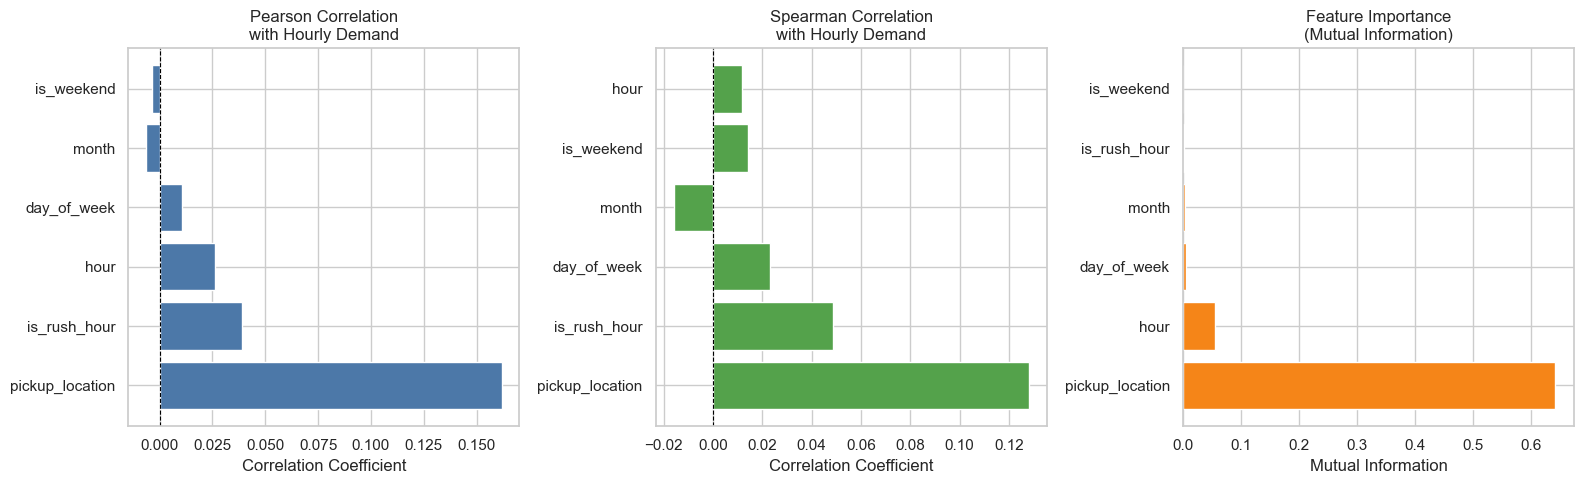

In [11]:
from scipy.stats import spearmanr, pearsonr
from sklearn.feature_selection import mutual_info_regression
import numpy as np

# Engineer relevant temporal and location features
df['month'] = df['tpep_pickup_datetime'].dt.month
df['is_weekend'] = (df['pickup_day_of_week'] >= 5).astype(int)
df['is_rush_hour'] = ((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 10)) | ((df['pickup_hour'] >= 17) & (df['pickup_hour'] <= 19))
df['is_rush_hour'] = df['is_rush_hour'].astype(int)

# Prepare feature matrix with temporal and location features
feature_matrix = pd.DataFrame({
    'hour': df['pickup_hour'],
    'day_of_week': df['pickup_day_of_week'],
    'month': df['month'],
    'is_weekend': df['is_weekend'],
    'is_rush_hour': df['is_rush_hour'],
    'pickup_location': df['PULocationID']
})

# Create hourly aggregated demand
hourly_agg = df.groupby(['hour', 'PULocationID', 'pickup_day_of_week', 'month', 'is_weekend', 'is_rush_hour']).size()

# Build feature matrix from index values (all numeric now)
feature_matrix_agg = pd.DataFrame({
    'hour': hourly_agg.index.get_level_values('hour').astype(int),
    'day_of_week': hourly_agg.index.get_level_values('pickup_day_of_week').astype(int),
    'month': hourly_agg.index.get_level_values('month').astype(int),
    'is_weekend': hourly_agg.index.get_level_values('is_weekend').astype(int),
    'is_rush_hour': hourly_agg.index.get_level_values('is_rush_hour').astype(int),
    'pickup_location': hourly_agg.index.get_level_values('PULocationID').astype(int)
})
target_agg = hourly_agg.values.astype(float)

# 1. Pearson Correlation
print("=" * 80)
print("PEARSON CORRELATION (with hourly demand count)")
print("=" * 80)
pearson_corr = {}
for col in feature_matrix_agg.columns:
    corr, pval = pearsonr(feature_matrix_agg[col].values.astype(float), target_agg)
    pearson_corr[col] = corr
    print(f"{col:30s}: {corr:7.4f}  (p-value: {pval:.2e})")

# 2. Spearman Correlation
print("\n" + "=" * 80)
print("SPEARMAN CORRELATION (with hourly demand count)")
print("=" * 80)
spearman_corr = {}
for col in feature_matrix_agg.columns:
    corr, pval = spearmanr(feature_matrix_agg[col].values.astype(float), target_agg)
    spearman_corr[col] = corr
    print(f"{col:30s}: {corr:7.4f}  (p-value: {pval:.2e})")

# 3. Mutual Information
print("\n" + "=" * 80)
print("MUTUAL INFORMATION (with hourly demand count)")
print("=" * 80)
mi_scores = mutual_info_regression(feature_matrix_agg.values.astype(float), target_agg, random_state=42)
mi_dict = dict(zip(feature_matrix_agg.columns, mi_scores))
for col in sorted(mi_dict.items(), key=lambda x: -x[1]):
    print(f"{col[0]:30s}: {col[1]:7.4f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pearson
pearson_sorted = dict(sorted(pearson_corr.items(), key=lambda x: abs(x[1]), reverse=True))
axes[0].barh(list(pearson_sorted.keys()), list(pearson_sorted.values()), color='#4C78A8')
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title('Pearson Correlation\nwith Hourly Demand')
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Spearman
spearman_sorted = dict(sorted(spearman_corr.items(), key=lambda x: abs(x[1]), reverse=True))
axes[1].barh(list(spearman_sorted.keys()), list(spearman_sorted.values()), color='#54A24B')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title('Spearman Correlation\nwith Hourly Demand')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.8)

# Mutual Information
mi_sorted = dict(sorted(mi_dict.items(), key=lambda x: x[1], reverse=True))
axes[2].barh(list(mi_sorted.keys()), list(mi_sorted.values()), color='#F58518')
axes[2].set_xlabel('Mutual Information')
axes[2].set_title('Feature Importance\n(Mutual Information)')

plt.tight_layout()
plt.show()

## DATA THRESHOLD DECISIONS FOR COLUMNS

Hourly demand by pickup location